In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\sanje\OneDrive\Desktop\mall\Mall_Customers.csv")

checking the head and tail of dataset

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


checking the shape of dataset


In [10]:
df.shape

(200, 5)

In [11]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [16]:
df.dtypes

CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

In [20]:
df.drop(["CustomerID"],axis=1, inplace=True)

In [21]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


C:\Users\sanje\AppData\Local\Temp\ipykernel_11324\1724787404.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[x], bins=20)
C:\Users\sanje\AppData\Local\Temp\ipykernel_11324\1724787404.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[x], bins=20)
C:\Users\sanje\AppData\Local\Temp\ipyk

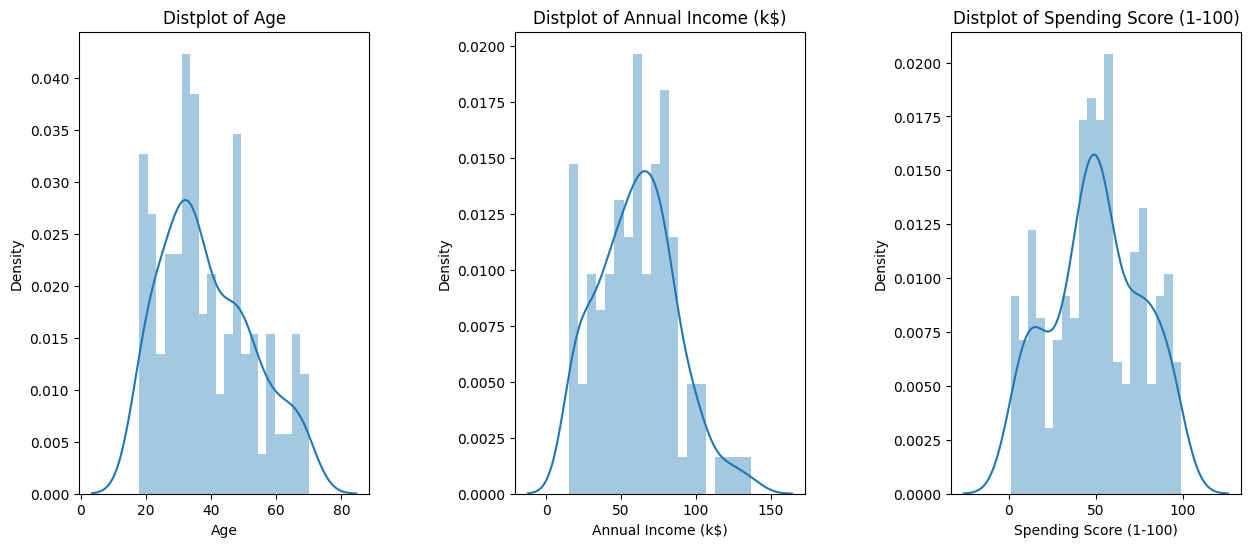

In [26]:
plt.figure(1, figsize=(15,6))
n = 0

for x in ["Age", "Annual Income (k$)", "Spending Score (1-100)"]:
    n += 1
    plt.subplot(1,3,n)
    plt.subplots_adjust(hspace=0.5, wspace=0.5)
    sns.distplot(df[x], bins=20)
    plt.title("Distplot of {}".format(x))

plt.show()

above warning is not the error its just a warning that the function might get change with the newwer version of python

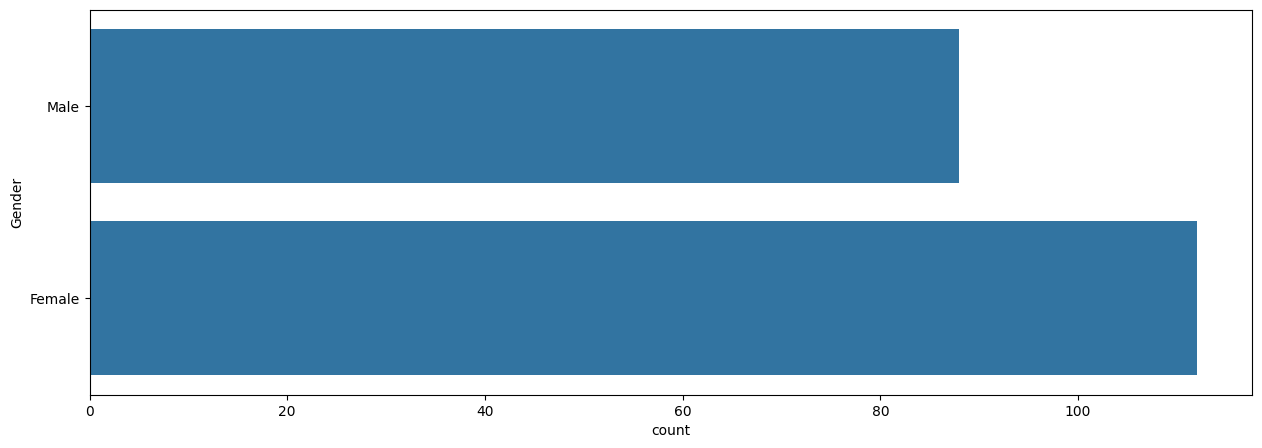

In [29]:
plt.figure(figsize = (15,5))
sns.countplot(y='Gender',data=df)
plt.show()

graph banauna ko lage according to the gender 

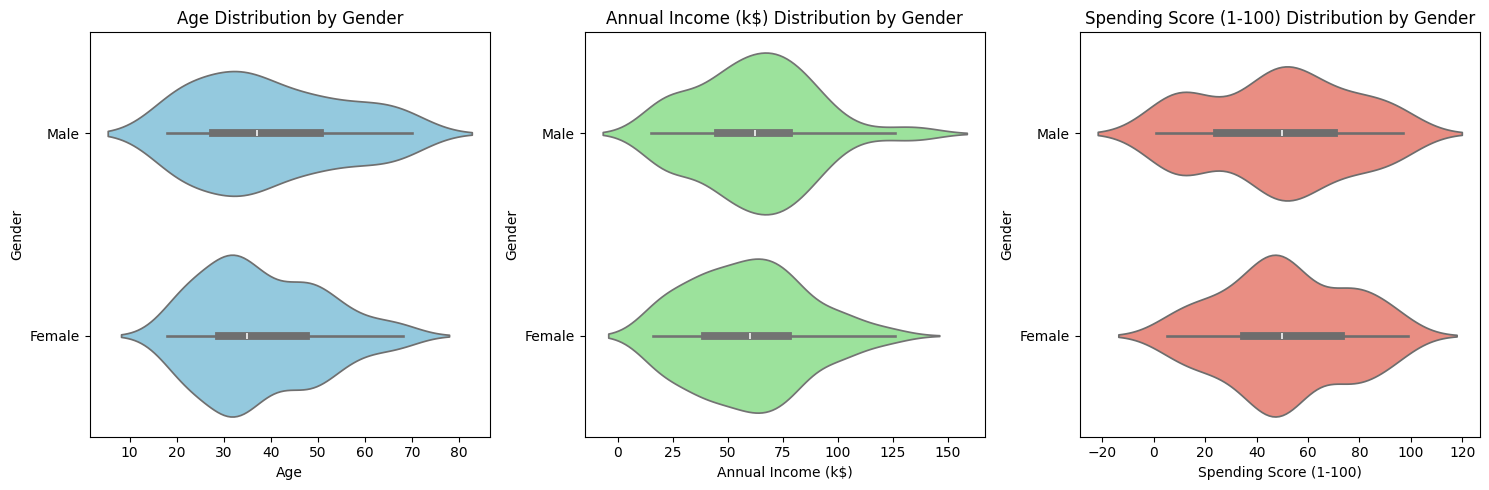

In [37]:
plt.figure(figsize=(15,5))

columns = ['Age','Annual Income (k$)','Spending Score (1-100)']
colors = ['skyblue','lightgreen','salmon']

for i, col in enumerate(columns):
    plt.subplot(1,3,i+1)
    sns.violinplot(y='Gender', x=col, data=df, color=colors[i])
    plt.title(f'{col} Distribution by Gender')

plt.tight_layout()
plt.show()

For more details trying to divide according to age 

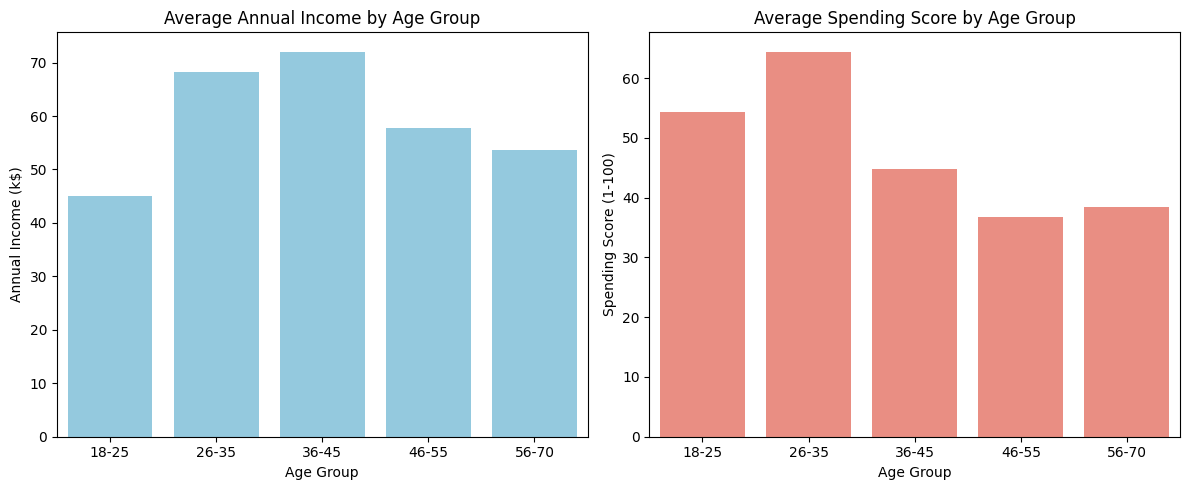

In [40]:
df['Age Group'] = pd.cut(df['Age'],
                         bins=[18,25,35,45,55,70],
                         labels=['18-25','26-35','36-45','46-55','56-70'])

# Age group अनुसार Average निकाल्ने
agg_df = df.groupby('Age Group')[['Annual Income (k$)','Spending Score (1-100)']].mean().reset_index()

plt.figure(figsize=(12,5))

# Bar plot for Annual Income
plt.subplot(1,2,1)
sns.barplot(x='Age Group', y='Annual Income (k$)', data=agg_df, color='skyblue')
plt.title('Average Annual Income by Age Group')

# Bar plot for Spending Score
plt.subplot(1,2,2)
sns.barplot(x='Age Group', y='Spending Score (1-100)', data=agg_df, color='salmon')
plt.title('Average Spending Score by Age Group')

plt.tight_layout()
plt.show()

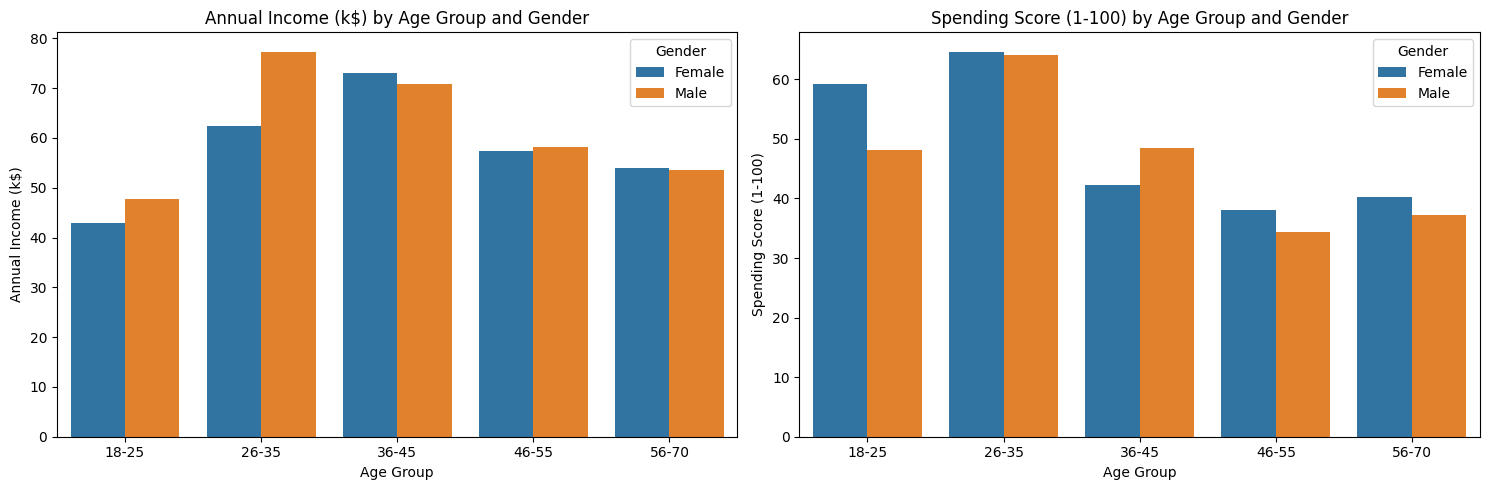

In [41]:
df['Age Group'] = pd.cut(df['Age'],
                         bins=[18,25,35,45,55,70],
                         labels=['18-25','26-35','36-45','46-55','56-70'])

# Age Group र Gender अनुसार Average निकाल्ने
agg_df = df.groupby(['Age Group','Gender'])[['Annual Income (k$)','Spending Score (1-100)']].mean().reset_index()

plt.figure(figsize=(15,5))

columns = ['Annual Income (k$)','Spending Score (1-100)']
colors = ['skyblue','salmon']

for i, col in enumerate(columns):
    plt.subplot(1,2,i+1)
    sns.barplot(x='Age Group', y=col, hue='Gender', data=agg_df)
    plt.title(f'{col} by Age Group and Gender')
    plt.legend(title='Gender')

plt.tight_layout()
plt.show()

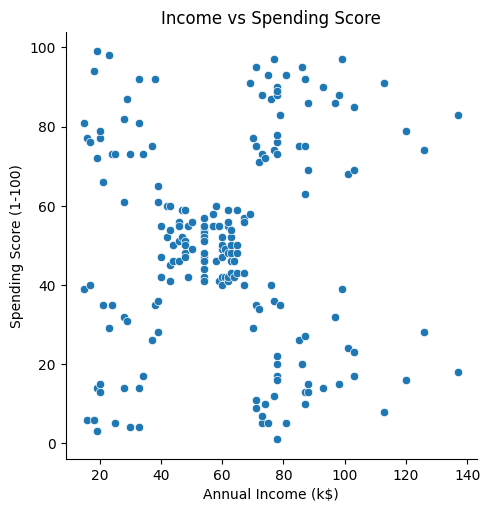

In [10]:
sns.relplot(x="Annual Income (k$)", y="Spending Score (1-100)", data=df)

plt.title("Income vs Spending Score")
plt.show()

dividing the spending score wih the category

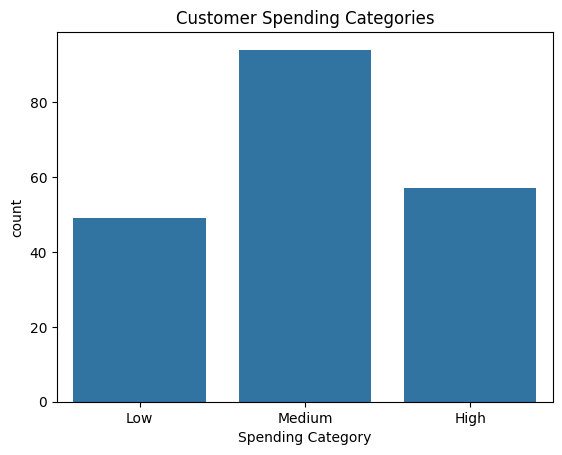

In [22]:
sns.countplot(x="Spending Category", data=df)

plt.title("Customer Spending Categories")
plt.show()

C:\Users\sanje\AppData\Local\Temp\ipykernel_688\2115592138.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Score Range", data=df, palette="Set2")


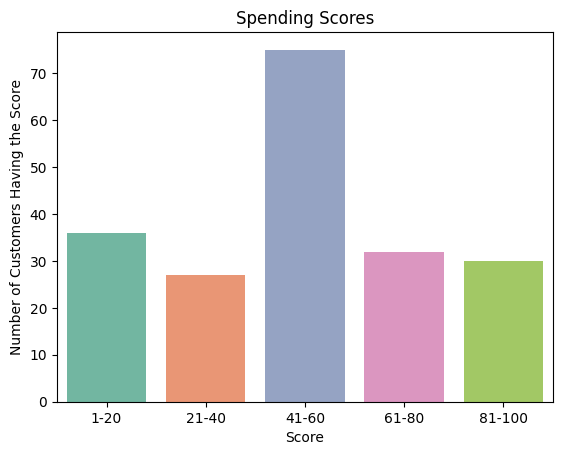

In [16]:
bins = [0,20,40,60,80,100]
labels = ["1-20","21-40","41-60","61-80","81-100"]

df["Score Range"] = pd.cut(df["Spending Score (1-100)"], bins=bins, labels=labels)

sns.countplot(x="Score Range", data=df, palette="Set2")

plt.title("Spending Scores")
plt.xlabel("Score")
plt.ylabel("Number of Customers Having the Score")

plt.show()

now for the annual income 

Which age group has the most customers

C:\Users\sanje\AppData\Local\Temp\ipykernel_8484\2669142552.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=agex, y=agey, palette="mako")


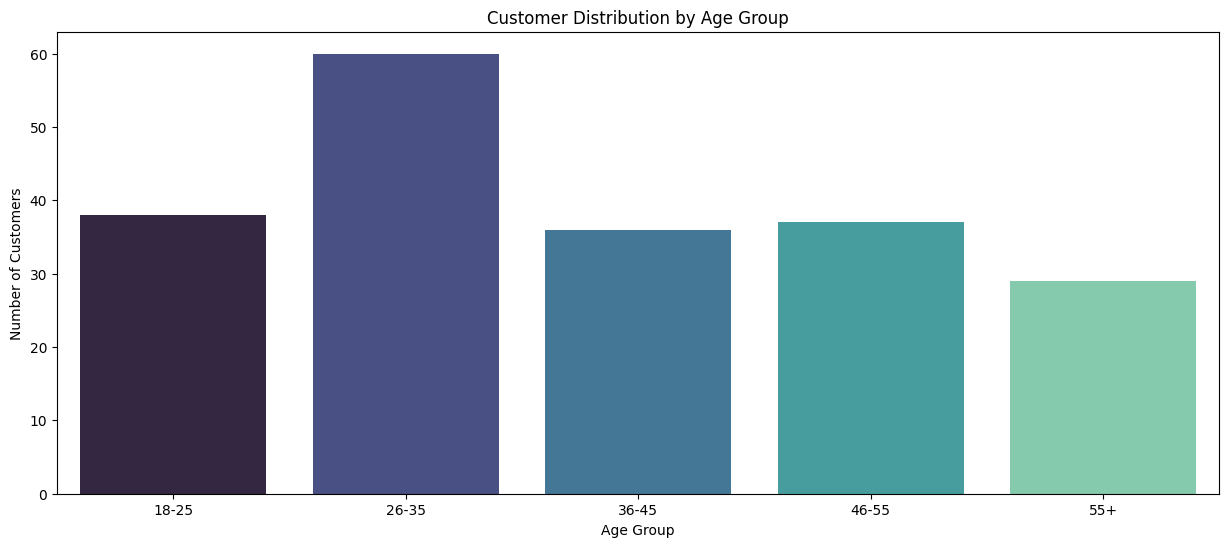

In [4]:
age_18_25 = df.Age[(df.Age >= 18) & (df.Age <= 25)]
age_26_35 = df.Age[(df.Age >= 26) & (df.Age <= 35)]
age_36_45 = df.Age[(df.Age >= 36) & (df.Age <= 45)]
age_46_55 = df.Age[(df.Age >= 46) & (df.Age <= 55)]
age_55above = df.Age[df.Age >= 56]

# X-axis labels
agex = ["18-25","26-35","36-45","46-55","55+"]

# Count customers in each group
agey = [
len(age_18_25.values),
len(age_26_35.values),
len(age_36_45.values),
len(age_46_55.values),
len(age_55above.values)
]

# Create bar graph
plt.figure(figsize=(15,6))

sns.barplot(x=agex, y=agey, palette="mako")

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

plt.show()

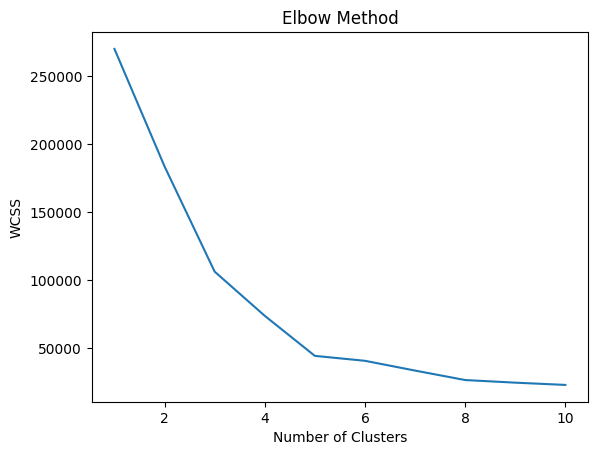

In [7]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, init="k-means++", random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [11]:
kmeans = KMeans(n_clusters=5, init="k-means++", random_state=42)

y_kmeans = kmeans.fit_predict(X)

df["Cluster"] = y_kmeans
print(y_kmeans)

[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


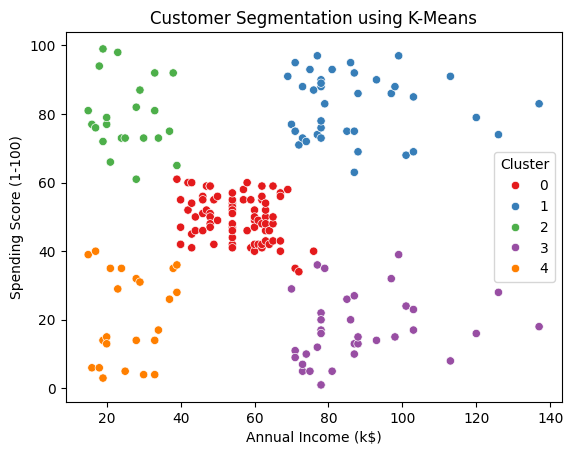

In [9]:
sns.scatterplot(
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set1",
    data=df
)

plt.title("Customer Segmentation using K-Means")
plt.show()